In [1]:
import sys
sys.path.append("../")
import numpy as np

#load the necessary odometry modules
from odometry.datasets.map_handler import MapHandler
from odometry.datasets.radnav_ds import radnavDS
from odometry.test_benches.icp2D_localization_tb import icp2DLocalizationTB
from odometry.localization.icp2D_localization import icp2DLocalization

In [2]:
#setup the datasets
dataset = radnavDS(
    dataset_path="/data/radnav/athena/athena_test_2/",
    radar_folder="radar_combined",
    lidar_folder="lidar",
    camera_folder="camera",
    imu_orientation_folder="imu_data",
    imu_full_folder="imu_data_full",
    vehicle_vel_folder="vehicle_vel"
)

#load the map
map_handler = MapHandler(
    maps_folder="/data/radnav/maps",
    map_file="athena.yaml"
)

found 284 radar samples
found 284 lidar samples
found 284 camera samples
found 284 imu (orientation only) samples
found 284imu (full data) samples
found 284 vehicle velocity samples
loaded map from /data/radnav/maps/athena.yaml


In [3]:
#initialize the localizers
radar_odometry = icp2DLocalization(
    icp_matching_distance_threshold=0.5,
    icp_best_points_percentile=40,
    icp_convergence_translation_threshold=1e-3,
    icp_convergence_rotation_threshold=1e-4,
    icp_point_pairs_threshold=10,
    icp_max_iterations=20,
    self_detection_radius_m=0.25
)

lidar_odometry = icp2DLocalization(
    icp_matching_distance_threshold=0.6,
    icp_best_points_percentile=50,
    icp_convergence_translation_threshold=1e-3,
    icp_convergence_rotation_threshold=1e-4,
    icp_point_pairs_threshold=10,
    icp_max_iterations=20,
    self_detection_radius_m=0.25
)

loaded map with 625 points
loaded map with 625 points
icp estimated heading:-1.2720800529317324 deg, pose:[-0.02594576  0.0252684 ]


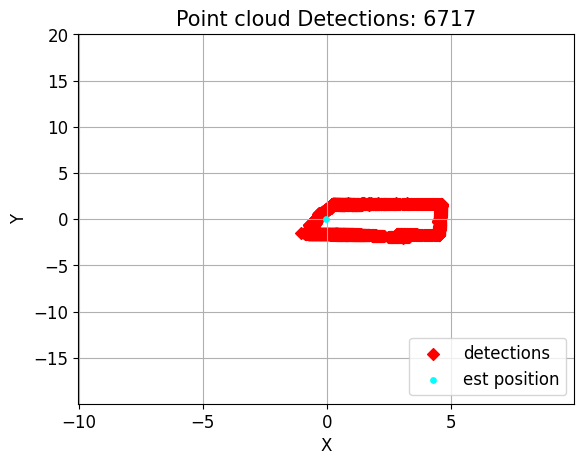

In [4]:
#initialize the test bench
test_bench = icp2DLocalizationTB(
    localizer=radar_odometry,
    gt_localizer=lidar_odometry,
    map_handler=map_handler,
    dataset=dataset
)

start_heading = np.deg2rad(0)
start_pose = np.array([0.0,0.0])

test_bench.init_localization(
    est_start_heading_rad=np.deg2rad(0),
    est_start_pose_m=np.array([0.0,0.0]),
    show=True
)


In [5]:
test_bench.run()

100%|██████████| 284/284 [00:16<00:00, 17.56it/s]


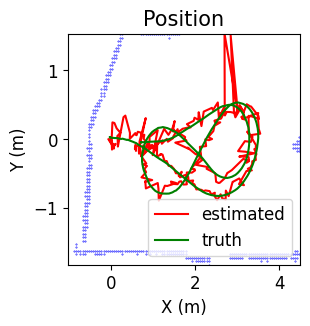

In [6]:
test_bench.plotter.plot_position_history_m(
    history_position_m=test_bench.history_position_m,
    history_position_m_gt=test_bench.history_position_m_gt,
    idx=0,
    ax=None,
    show=True
)

In [7]:
test_bench.analyze()

,Metric,Euclidian,x,y,phi
0,Mean,0.132680,0.012983,-0.017781,0.010596
1,Variance,0.011585,0.011074,0.017629,0.003966
2,Median,0.118341,-0.003091,-0.003375,0.012119
3,0.9th percentile,0.218463,0.170300,0.166485,0.093987
